In [ ]:
import torch
from torch import nn

In [ ]:
 device = "cuda" if torch.cuda.is_available() else "cpu"
 print(device)

cuda


In [ ]:
weight = 2.23
bias = 22.12341

start = 0
end = 1

x=torch.linspace(start , end , 100)
y=weight*x+bias


In [ ]:
x , y

(tensor([0.0000, 0.0417, 0.0833, 0.1250, 0.1667, 0.2083, 0.2500, 0.2917, 0.3333,
         0.3750, 0.4167, 0.4583, 0.5000, 0.5417, 0.5833, 0.6250, 0.6667, 0.7083,
         0.7500, 0.7917, 0.8333, 0.8750, 0.9167, 0.9583, 1.0000]),
 tensor([22.1234, 22.2163, 22.3092, 22.4022, 22.4951, 22.5880, 22.6809, 22.7738,
         22.8667, 22.9597, 23.0526, 23.1455, 23.2384, 23.3313, 23.4242, 23.5172,
         23.6101, 23.7030, 23.7959, 23.8888, 23.9817, 24.0747, 24.1676, 24.2605,
         24.3534]))

In [ ]:
#split

train_spilit = int(0.8*len(x))
x_train , y_train = x[:train_spilit]  , y[:train_spilit]
x_test , y_test = x[train_spilit:] , y[train_spilit:]

In [ ]:
len(x_train) , len(y_train)


(80, 80)

In [ ]:
len(x_test) , len(y_test)

(20, 20)

In [ ]:

import matplotlib.pyplot as plt

In [ ]:
def plot_predictions(train_data = x_train , trains_labels=y_train , test_data=x_test , test_labels=y_test , predictions=None):
  plt.figure(figsize=(10,7))
  plt.scatter(train_data , trains_labels , c='r' , s=4 , label='train data')
  plt.scatter(test_data , test_labels , c='b' , s=4 , label='test data')

  if predictions is not None:
    plt.scatter(test_data , predictions , c='g' , s=4 , label="predicted data")
  plt.legend(prop={'size':14})
  plt.show()

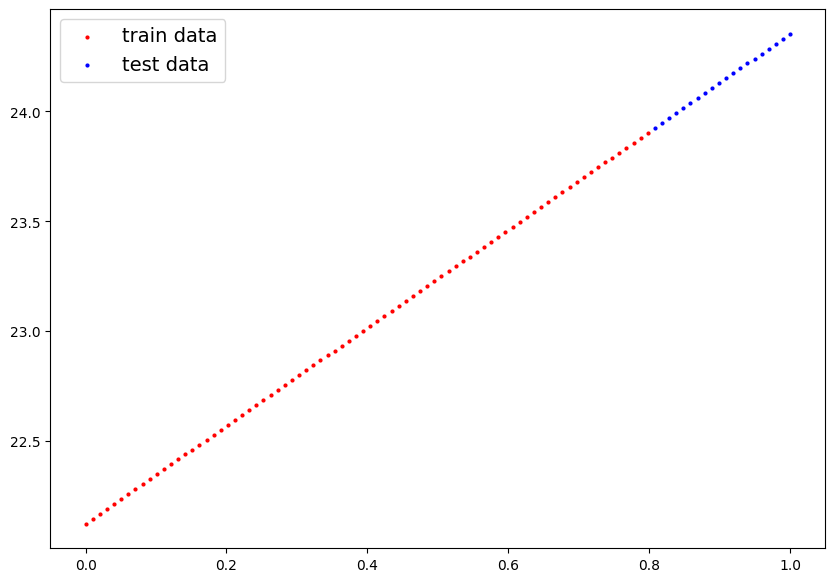

In [ ]:
plot_predictions()

In [ ]:
# linear reg model

class LineraRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    #simplified the bias and w code and forward using nn linear

    self.linear_layer = nn.Linear(in_features=1 , out_features=1)


  def forward(self , x:torch.Tensor)->torch.Tensor:
    return self.linear_layer(x)




In [ ]:
  torch.manual_seed(42)
  model=LineraRegressionModel()
  model.state_dict()


OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [ ]:

#training part
#loss func  - l1loss is mae
# optimizer - sgd stocastic grad descent

# training loop
# testing loop


In [ ]:
loss_fn = nn.L1Loss()
opitmizer = torch.optim.SGD(params=model.parameters() , lr=0.01)

In [ ]:
torch.manual_seed(23)
epochs = 200000

# Reshape data to be compatible with nn.Linear (expects input of shape (N, in_features))
# x_train_reshaped = x_train.unsqueeze(dim=1)
# y_train_reshaped = y_train.unsqueeze(dim=1)
# x_test_reshaped = x_test.unsqueeze(dim=1)
# y_test_reshaped = y_test.unsqueeze(dim=1)

for epoch in range(epochs):
  model.train()

  # 1. Forward pass
  y_pred = model(x_train_reshaped)

  # 2. Calculate loss
  loss = loss_fn(y_pred , y_train_reshaped)

  # 3. Optimizer zero grad
  opitmizer.zero_grad()

  # 4. Perform backpropagation
  loss.backward()

  # 5. Optimizer step
  opitmizer.step()

  # Testing loop
  model.eval()
  with torch.no_grad():
    test_pred = model(x_test_reshaped)
    test_loss = loss_fn(test_pred , y_test_reshaped)

  # Print out what's happening every 10 epochs
  if epoch % 10000 == 0:
    print(f"Epoch: {epoch} | Train loss: {loss:.4f} | Test loss: {test_loss:.4f}")

Epoch: 0 | Train loss: 0.0078 | Test loss: 0.0076
Epoch: 10000 | Train loss: 0.0078 | Test loss: 0.0076
Epoch: 20000 | Train loss: 0.0078 | Test loss: 0.0076
Epoch: 30000 | Train loss: 0.0078 | Test loss: 0.0076
Epoch: 40000 | Train loss: 0.0078 | Test loss: 0.0076
Epoch: 50000 | Train loss: 0.0078 | Test loss: 0.0076
Epoch: 60000 | Train loss: 0.0078 | Test loss: 0.0076
Epoch: 70000 | Train loss: 0.0078 | Test loss: 0.0076
Epoch: 80000 | Train loss: 0.0078 | Test loss: 0.0076
Epoch: 90000 | Train loss: 0.0078 | Test loss: 0.0076
Epoch: 100000 | Train loss: 0.0078 | Test loss: 0.0076
Epoch: 110000 | Train loss: 0.0078 | Test loss: 0.0076
Epoch: 120000 | Train loss: 0.0078 | Test loss: 0.0076
Epoch: 130000 | Train loss: 0.0078 | Test loss: 0.0076
Epoch: 140000 | Train loss: 0.0078 | Test loss: 0.0076
Epoch: 150000 | Train loss: 0.0078 | Test loss: 0.0076
Epoch: 160000 | Train loss: 0.0078 | Test loss: 0.0076
Epoch: 170000 | Train loss: 0.0078 | Test loss: 0.0076
Epoch: 180000 | Train lo

In [ ]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[2.2335]])),
             ('linear_layer.bias', tensor([22.1142]))])

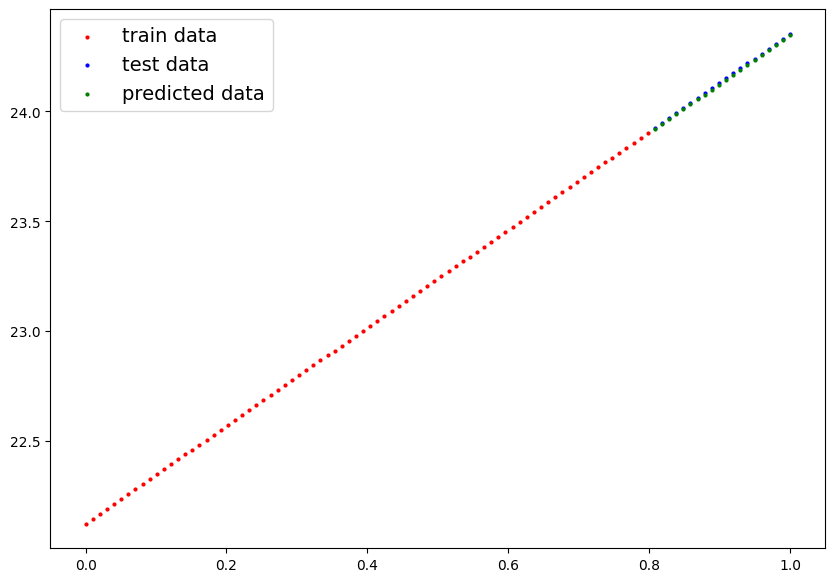

In [ ]:
x_train_reshaped = x_train.unsqueeze(dim=1)
y_train_reshaped = y_train.unsqueeze(dim=1)
x_test_reshaped = x_test.unsqueeze(dim=1)
y_test_reshaped = y_test.unsqueeze(dim=1)
with torch.inference_mode():
  y_preds = model(x_test_reshaped)

y_preds_reshaped = y_preds.unsqueeze(dim=1)
y_preds_reshaped , y_test_reshaped
plot_predictions(predictions=y_preds)